# Basic Usage Tutorial

This tutorial will walk you through the basic workflow of using Neurodent for rodent EEG analysis.

## Overview

Neurodent provides a streamlined workflow for:
1. Loading EEG recordings from various formats
2. Extracting features from continuous data (Windowed Analysis)
3. Visualizing and analyzing results

Let's get started!

## 1. Installation and Setup

First, ensure you have Neurodent installed. See the [Installation Guide](../installation/index.html) for detailed instructions.

```bash
pip install neurodent
```

Or with uv:
```bash
uv init yourprojectname
cd yourprojectname
uv add neurodent
```

## 2. Import Required Modules

Let's import the necessary modules from Neurodent:

> **Tip:** To see detailed progress information during processing, check out the [Configuration Guide](configuration.ipynb) to learn how to enable logging.


In [1]:
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

from neurodent import (
    LongRecordingOrganizer,
    AnimalOrganizer,
    AnimalAnalyzer,
    WindowAnalysisResult,
    AnimalPlotter,
    ExperimentPlotter,
    set_channel_map,
)
from neurodent.core.utils import get_temp_directory, set_temp_directory

/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_channel_map({
    "LMot": ["C-015", "D-015"],
    "RMot": ["C-016", "D-016"],
    "LBar": ["C-014", "D-014"],
    "RBar": ["C-017", "D-017"],
    "LHip": ["C-012", "D-012"],
    "RHip": ["C-019", "D-019"],
    "LAud": ["C-009", "D-009"],
    "RAud": ["C-022", "D-022"],
    "LVis": ["C-010", "D-010"],
    "RVis": ["C-021", "D-021"],
})

## 3. Configure Temporary Directory (Optional)

Neurodent uses a temporary directory for intermediate files during processing. You can set this to a location with sufficient space:

In [3]:
# Set temporary directory for intermediate files
# set_temp_directory("/path/to/your/temp/dir")

# Or use the default temp directory
print(f"Using temp directory: {get_temp_directory()}")

Using temp directory: /tmp


## 4. Load EEG Data

Neurodent supports multiple data formats through `LongRecordingOrganizer` (LRO):
- **SpikeInterface mode** (`mode="si"`): Load any format supported by SpikeInterface (EDF, NWB, Open Ephys, Neuralynx, binary, etc.). Use `extract_func` for custom readers.
- **MNE mode** (`mode="mne"`): Load any format supported by MNE-Python.
- **Pre-created recording** (`mode=None, recording=...`): Pass an already-loaded SpikeInterface `BaseRecording` directly.

### Loading a single file

The simplest way to load data is to point LRO to a file path.  Here we
load a small EDF recording shipped with the repository:

In [4]:
# Load an EDF file by passing a single path
lro = LongRecordingOrganizer(
    item="../../.tests/integration/data/A10/A10_recording.edf",
    mode="si",
    extract_func="read_edf",
    manual_datetimes=datetime(2023, 12, 13),
)

print(f"Sampling frequency: {lro.meta.f_s}")
print(f"Number of channels: {lro.meta.n_channels}")
print(f"Duration: {lro.LongRecording.get_total_duration():.1f} s")

Sampling frequency: 1000.0
Number of channels: 10
Duration: 5.0 s


### Loading multi-file formats with ``DiscoveredFile``

Some formats consist of multiple files per recording (e.g. a `.bin`
data file paired with a `.csv` metadata file).  Wrap these paths in
a `DiscoveredFile` so the LRO treats them as a single unit:

In [5]:
from neurodent.loading import DiscoveredFile

# Two files that together form one recording
discovered = DiscoveredFile(
    paths=(
        "../../.tests/integration/data/A10/Cage 2 A10-0_ColMajor.bin",
        "../../.tests/integration/data/A10/Cage 2 A10-0_Meta.csv",
    ),
)

lro_bin = LongRecordingOrganizer(
    item=discovered,
    mode="si",
    extract_func="../../tests/integration/readers.py:read_bin_csv_pair",
    manual_datetimes=datetime(2023, 12, 13),
)

print(f"Sampling frequency: {lro_bin.meta.f_s}")
print(f"Number of channels: {lro_bin.meta.n_channels}")
print(f"Channel names: {lro_bin.meta.channel_names}")

Sampling frequency: 1000.0
Number of channels: 10
Channel names: ['C-009', 'C-010', 'C-012', 'C-014', 'C-015', 'C-016', 'C-017', 'C-019', 'C-021', 'C-022']


## 5. Create Animal Organizer

The `AnimalOrganizer` (AO) uses placeholder patterns (e.g. `{animal}`,
`{session}`) to discover and group recordings automatically.  For
multi-file formats, pass a **list** of patterns — one per file type:

In [6]:
# Multi-pattern for paired bin/csv files
ao = AnimalOrganizer(
    pattern=[
        "../../.tests/integration/data/{animal}/*_ColMajor.bin",
        "../../.tests/integration/data/{animal}/*_Meta.csv",
    ],
    animal_id="A10",
    lro_kwargs={
        "mode": "si",
        "extract_func": "../../tests/integration/readers.py:read_bin_csv_pair",
        "manual_datetimes": datetime(2023, 12, 13),
    },
)

print(f"Animal Organizer created for {ao.animal_id}")

Animal Organizer created for A10


## 6. Compute Windowed Analysis Results (WAR)

Now we can compute features from the EEG data. Neurodent extracts features in time windows:

### Available Features:

**Linear Features** (per channel):
- `rms`: RMS amplitude
- `logrms`: Log RMS amplitude
- `ampvar`: Amplitude variance
- `logampvar`: Log amplitude variance
- `psdtotal`: Total PSD power
- `logpsdtotal`: Log total PSD power
- `psdslope`: PSD slope
- `nspike`: Number of spikes detected
- `lognspike`: Log number of spikes

**Band Features** (per frequency band: delta, theta, alpha, beta, gamma):
- `psdband`: Band power
- `logpsdband`: Log band power
- `psdfrac`: Fractional band power
- `logpsdfrac`: Log fractional band power

**Connectivity/Matrix Features** (between channels):
- `cohere`: Coherence
- `zcohere`: Z-scored coherence
- `imcoh`: Imaginary coherence
- `zimcoh`: Z-scored imaginary coherence
- `pcorr`: Pearson correlation
- `zpcorr`: Z-scored Pearson correlation

**Spectral Features**:
- `psd`: Full power spectral density

In [7]:
# Compute windowed analysis with selected features
# You can specify 'all' or list specific features
features = ['rms', 'psdband', 'cohere', 'psd']

war = AnimalAnalyzer(ao).compute_windowed_analysis(
    features=features,
    multiprocess_mode='serial'  # Options: 'serial', 'multiprocess', 'dask'
)

print(f"Windowed analysis completed!")
print(f"Features computed: {features}")

Processing rows:  88%|████████▊ | 22/25 [00:00<00:00, 29.06it/s]
/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1000 is greater than input length  = 360, using nperseg = 360
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/runner/work/neurodent/neurodent/src/neurodent/analysis/fragment_analyzer.py:423: RuntimeWarning: fmin=1.000 Hz corresponds to 0.360 < 5 cycles based on the epoch length 0.360 sec, need at least 5.000 sec epochs or fmin=13.889. Spectrum estimate will be unreliable.
  con = spectral_connectivity_epochs(
/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1000 is greater than input length  = 360, using nperseg = 360
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
Processing rows: 100%|██████████| 25/25 [00:00<00:00, 30.12it/s]

/home/runner/work/neurodent/neur

Processing rows:  12%|█▏        | 3/25 [00:00<00:00, 29.85it/s]

Processing rows:  28%|██▊       | 7/25 [00:00<00:00, 30.01it/s]

Processing rows:  40%|████      | 10/25 [00:00<00:00, 29.85it/s]

Processing rows:  52%|█████▏    | 13/25 [00:00<00:00, 29.61it/s]

...

Processing rows:  76%|███████▌  | 19/25 [00:00<00:00, 29.29it/s]

Processing rows:  88%|████████▊ | 22/25 [00:00<00:00, 29.06it/s]

/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1000 is greater than input length  = 360, using nperseg = 360
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/runner/work/neurodent/neurodent/src/neurodent/analysis/fragment_analyzer.py:423: RuntimeWarning: fmin=1.000 Hz corresponds to 0.360 < 5 cycles based on the epoch length 0.360 sec, need at least 5.000 sec epochs or fmin=13.889. Spectrum estimate will be unreliable.
  con = spectral_connectivity_epochs(
/home/runner/work/neurodent/neurodent/.venv/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 1000 is greater than input length  = 360, using nperseg = 360
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
Processing rows: 100%|██████████| 25/25 [00:00<00:00, 30.12it/s]

/home/runner/work/neurodent/neurodent/src/neurodent/analysis/animal_analyzer.py:330: UserWarning: WARNING: 1 animalday(s) are missing LOF scores: ['A10 Unknown Dec-13-2023']. Expected 1 but got 0. These sessions will be auto-populated with empty placeholders and excluded from LOF-based analysis.
  warnings.warn(warning_msg)


Windowed analysis completed!
Features computed: ['rms', 'psdband', 'cohere', 'psd']


## 7. Filter and Clean Data

Neurodent provides filtering methods to remove artifacts and outliers:

In [8]:
# Apply filtering using method chaining
war_filtered = (
    war
    .filter_logrms_range(z_range=3)  # Remove outliers based on log RMS
    .filter_high_rms(max_rms=500)     # Remove high amplitude artifacts
    .filter_low_rms(min_rms=10)       # Remove low amplitude periods
)

print("Filtering completed!")

Filtering completed!


## 8. Basic Visualization

### Single Animal Plots

Use `AnimalPlotter` to visualize data over time from a single animal. **Note**: Do NOT aggregate time windows before plotting - the plotter needs the temporal data intact:

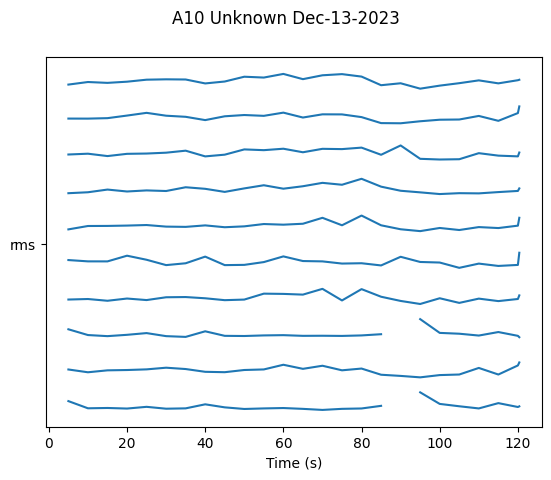

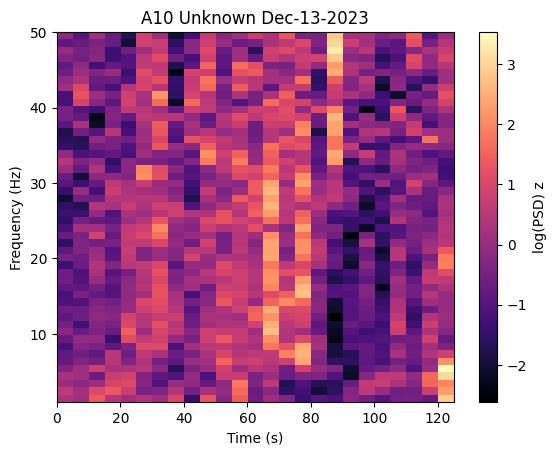

In [9]:
# Create plotter for single animal
ap = AnimalPlotter(war_filtered)

# Plot RMS over time
fig = ap.plot_linear_temporal(features=['rms'])
plt.show()

# Plot PSD band powers
fig = ap.plot_psd_spectrogram()
plt.show()

## 9. Aggregate Time Windows (Optional)

You can flatten all windows into a single value by averaging across time. This saves memory and gives you a summary statistic across an entire session.

> **Note:** You should not aggregate before plotting time-series data with `AnimalPlotter`, as this removes the temporal information needed for over-time visualizations.

In [10]:
# Example: Aggregate for summary statistics
# Only do this if you need a single value per animal/session
war_aggregated = war_filtered.copy()
war_aggregated.aggregate_time_windows()

/home/runner/work/neurodent/neurodent/src/neurodent/results/window_analysis_result.py:561: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated_df = result_grouped.apply(


### Multi-Animal Comparison

To compare across multiple animals, use `ExperimentPlotter`.  Here we
build a second WAR for animal F22 so we can compare the two:

Processing rows:  98%|█████████▊| 92/94 [00:03<00:00, 28.19it/s]
/home/runner/work/neurodent/neurodent/src/neurodent/analysis/fragment_analyzer.py:423: RuntimeWarning: fmin=1.000 Hz corresponds to 1.440 < 5 cycles based on the epoch length 1.440 sec, need at least 5.000 sec epochs or fmin=3.472. Spectrum estimate will be unreliable.
  con = spectral_connectivity_epochs(
Processing rows: 100%|██████████| 94/94 [00:03<00:00, 29.25it/s]

/home/runner/work/neurodent/neurodent/src/neurodent/analysis/animal_analyzer.py:330: UserWarning: WARNING: 1 animalday(s) are missing LOF scores: ['F22 Unknown Dec-12-2023']. Expected 1 but got 0. These sessions will be auto-populated with empty placeholders and excluded from LOF-based analysis.
  warnings.warn(warning_msg)


Processing rows:   4%|▍         | 4/94 [00:00<00:02, 33.20it/s]

Processing rows:   7%|▋         | 7/94 [00:00<00:02, 31.43it/s]

Processing rows:  12%|█▏        | 11/94 [00:00<00:02, 30.87it/s]

Processing rows:  15%|█▍        | 14/94 [00:00<00:02, 30.37it/s]

...

Processing rows:  89%|████████▉ | 84/94 [00:02<00:00, 21.95it/s]

Processing rows:  94%|█████████▎| 88/94 [00:03<00:00, 25.33it/s]

Processing rows:  98%|█████████▊| 92/94 [00:03<00:00, 28.19it/s]

/home/runner/work/neurodent/neurodent/src/neurodent/analysis/fragment_analyzer.py:423: RuntimeWarning: fmin=1.000 Hz corresponds to 1.440 < 5 cycles based on the epoch length 1.440 sec, need at least 5.000 sec epochs or fmin=3.472. Spectrum estimate will be unreliable.
  con = spectral_connectivity_epochs(
Processing rows: 100%|██████████| 94/94 [00:03<00:00, 29.25it/s]

/home/runner/work/neurodent/neurodent/src/neurodent/analysis/animal_analyzer.py:330: UserWarning: WARNING: 1 animalday(s) are missing LOF scores: ['F22 Unknown Dec-12-2023']. Expected 1 but got 0. These sessions will be auto-populated with empty placeholders and excluded from LOF-based analysis.
  warnings.warn(warning_msg)


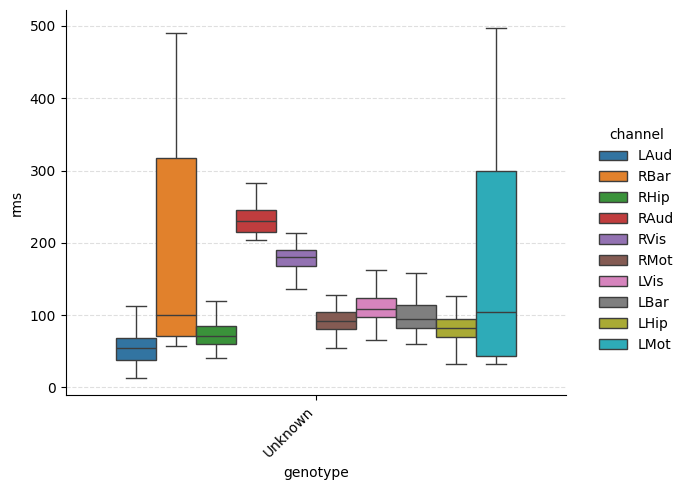

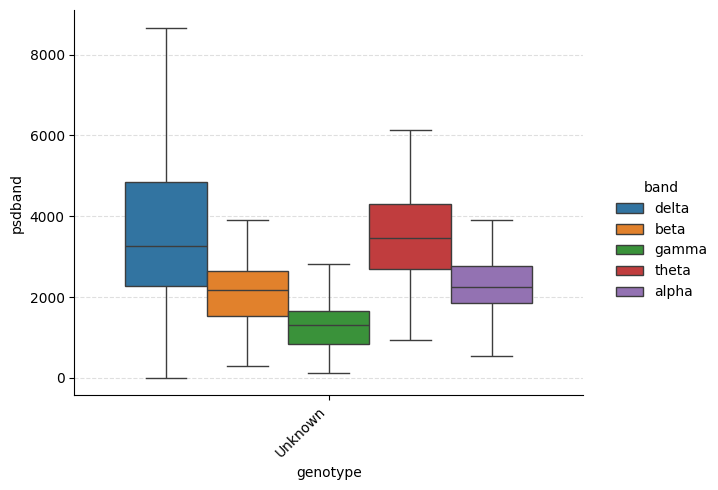

In [11]:
# Build a WAR for a second animal (F22)
ao_f22 = AnimalOrganizer(
    pattern=[
        "../../.tests/integration/data/{animal}/*_ColMajor.bin",
        "../../.tests/integration/data/{animal}/*_Meta.csv",
    ],
    animal_id="F22",
    lro_kwargs={
        "mode": "si",
        "extract_func": "../../tests/integration/readers.py:read_bin_csv_pair",
        "manual_datetimes": datetime(2023, 12, 12),
    },
)

war_f22 = AnimalAnalyzer(ao_f22).compute_windowed_analysis(
    features=features, multiprocess_mode="serial"
)
war_f22_filtered = (
    war_f22
    .filter_logrms_range(z_range=3)
    .filter_high_rms(max_rms=500)
    .filter_low_rms(min_rms=10)
)

# Create ExperimentPlotter with both animals
wars = [war_filtered, war_f22_filtered]

ep = ExperimentPlotter(
    wars,
    features=features,
    exclude=['nspike', 'lognspike'],
    plot_order={'genotype': ['Unknown']},  # genotype is set via samples config; 'Unknown' is the default
)

# Categorical plot grouped by genotype
g = ep.plot_catplot(
    'rms',
    groupby='genotype',
    kind='box',
    catplot_params={'showfliers': False},
)
plt.show()

# PSD band powers grouped by genotype
g = ep.plot_catplot(
    'psdband',
    groupby='genotype',
    x='genotype',
    hue='band',
    kind='box',
    collapse_channels=True,
    catplot_params={'showfliers': False},
)
plt.show()

## 10. Save Results

You can save your WAR objects for later analysis:

In [12]:
import tempfile

# Use a temporary directory for demonstration purposes
with tempfile.TemporaryDirectory() as tmpdir:
    output_path = Path(tmpdir) / "A10"
    output_path.mkdir(parents=True, exist_ok=True)

    # Save WAR
    war_filtered.save_pickle_and_json(folder=output_path)
    print(f"WAR saved to {output_path}")

    # Load WAR
    war_loaded = WindowAnalysisResult.load_pickle_and_json(output_path)
    print(f"Loaded result for {war_loaded.animal_id}")

WAR saved to /tmp/tmp04bw7ba7/A10
Loaded result for A10


/tmp/ipykernel_3951/527134319.py:9: DeprecationWarning: save_pickle_and_json is deprecated and no longer writes a pickle file; use save_parquet_and_json instead.
  war_filtered.save_pickle_and_json(folder=output_path)
/tmp/ipykernel_3951/527134319.py:13: DeprecationWarning: load_pickle_and_json is deprecated; use load_parquet_and_json instead.
  war_loaded = WindowAnalysisResult.load_pickle_and_json(output_path)


## Summary

In this tutorial, you learned how to:

1. Import and configure Neurodent
2. Load EEG data using `LongRecordingOrganizer` (single path and `DiscoveredFile`)
3. Create an `AnimalOrganizer` for feature extraction
4. Compute windowed analysis features (`WindowAnalysisResult`)
5. Filter and clean data
6. (Optionally) Aggregate time windows for summary statistics
7. Visualize results using `AnimalPlotter` and `ExperimentPlotter`
8. Save and load results

## Next Steps

- **[Data Loading Tutorial](data_loading.ipynb)**: Learn about loading different data formats
- **[Windowed Analysis Tutorial](../tutorials/windowed_analysis.ipynb)**: Deep dive into feature extraction
- **[Visualization Tutorial](../tutorials/visualization.ipynb)**: Advanced plotting techniques
- **[Spike Analysis Tutorial](../tutorials/spike_analysis.ipynb)**: Working with spike-sorted data